1D CNN MODEL

DATA LOADING AND PREPROCESSING

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

In [2]:
# Load data
train_df = pd.read_csv('/Users/mounikapolamreddy/Desktop/train.csv')
labels_df = pd.read_csv('/Users/mounikapolamreddy/Desktop/train_labels.csv')

In [3]:
# 1. Fill missing values (common in multi-exchange data)
train_df = train_df.sort_values('date_id').ffill().bfill()

In [4]:
# 2. Scale features (CNNs need normalized inputs)
feature_cols = [c for c in train_df.columns if c not in ['date_id']]
scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])

In [5]:
# 3. Create Sliding Windows
def create_windows(data, labels, window_size=30):
    X, y = [], []
    # We loop through the data to create (window_size) chunks
    for i in range(window_size, len(data)):
        X.append(data.iloc[i-window_size:i][feature_cols].values)
        y.append(labels.iloc[i][1:].values) # Skip date_id in labels
    return np.array(X), np.array(y)

In [6]:
# clean the labels
# This fixes the 86k NaNs we found in your y data
labels_df.iloc[:, 1:] = labels_df.iloc[:, 1:].fillna(0)

In [7]:
# define window size
WINDOW_SIZE = 30

In [8]:
# create windows
X, y = create_windows(train_df, labels_df, window_size=WINDOW_SIZE)
X = np.nan_to_num(X)
y = np.nan_to_num(y)

In [9]:
# Validate that there are no NaNs
print(f"Final check - Any NaNs in X? {np.isnan(X).any()}")
print(f"Final check - Any NaNs in y? {np.isnan(y).any()}")

print("NaNs in X:", np.isnan(X).sum())
print("NaNs in y:", np.isnan(y).sum())
print("Infs in X:", np.isinf(X).sum())

Final check - Any NaNs in X? False
Final check - Any NaNs in y? False
NaNs in X: 0
NaNs in y: 0
Infs in X: 0


In [10]:
print(f"Input Shape (Samples, TimeSteps, Features): {X.shape}")

Input Shape (Samples, TimeSteps, Features): (1931, 30, 557)


In [11]:
print(f"Output Shape (Samples, Targets): {y.shape}")

Output Shape (Samples, Targets): (1931, 424)


BUILDING 1D CNN MODEL

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

In [13]:
def build_refined_model(input_shape, output_dim):
    model = models.Sequential([
        # Layer 1: Smaller kernels often work better for daily financial data
        layers.Conv1D(32, kernel_size=3, padding='same', input_shape=input_shape,
                      kernel_regularizer=regularizers.l2(0.001)),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        
        # Layer 2: Deeper feature extraction
        layers.Conv1D(64, kernel_size=3, padding='same', 
                      kernel_regularizer=regularizers.l2(0.001)),
        layers.LeakyReLU(alpha=0.1),
        layers.Dropout(0.4), # Increased dropout because 1,931 samples is a small dataset
        
        layers.GlobalAveragePooling1D(),
        
        # Dense Layers
        layers.Dense(128),
        layers.LeakyReLU(alpha=0.1),
        layers.Dense(output_dim, activation='linear') 
    ])
    
    # Lower learning rate is usually safer for volatile commodity returns
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model
    

In [14]:
# Re-initialize with the refined architecture
model = build_refined_model((WINDOW_SIZE, X.shape[2]), y.shape[1])
model.summary()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 32)         │        53,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 15, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 424)            │        54,696 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,856 (479.91 KB)

 Trainable params: 122,792 (479.66 KB)

 Non-trainable params: 64 (256.00 B)

TRAINING AND VALIDATION

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [16]:
# 1. Chronological Split (No shuffling!)
split_idx = int(len(X) * 0.8)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

In [17]:
# 2. Callbacks for better training
callbacks = [
    # Stops training if val_loss doesn't improve for 5 epochs
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    # Lowers learning rate if the model plateaus
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

In [18]:
# 3. Train
history = model.fit(
    X_train, y_train,
    epochs=50, # Set high, EarlyStopping will cut it short
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0969 - mae: 0.0565 - val_loss: 0.0914 - val_mae: 0.1058 - learning_rate: 5.0000e-04
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0598 - mae: 0.0263 - val_loss: 0.0491 - val_mae: 0.0512 - learning_rate: 5.0000e-04
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0362 - mae: 0.0230 - val_loss: 0.0282 - val_mae: 0.0328 - learning_rate: 5.0000e-04
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0216 - mae: 0.0214 - val_loss: 0.0165 - val_mae: 0.0245 - learning_rate: 5.0000e-04
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0130 - mae: 0.0205 - val_loss: 0.0098 - val_mae: 0.0211 - learning_rate: 5.0000e-04
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0080 - mae: 0.0201 - val_loss: 0.0060 - val_mae: 0.0199 - learning_rate: 5.0000e-04
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0050 - mae: 0.0198 - val_loss: 0.0037 - val_mae: 0.0184 - learning_rate: 5

ENSURING DATA WAS PROCESSED WELL THROUGH VISUALIZATION

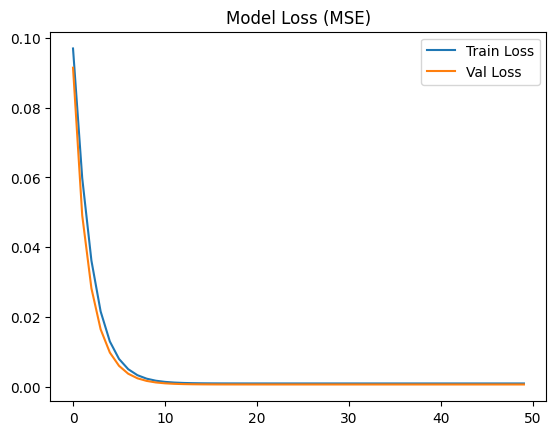

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss (MSE)')
plt.legend()
plt.show()

EVALUATE PERFORMANCE

In [20]:
# 1. Get predictions on the validation set
y_pred = model.predict(X_val)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


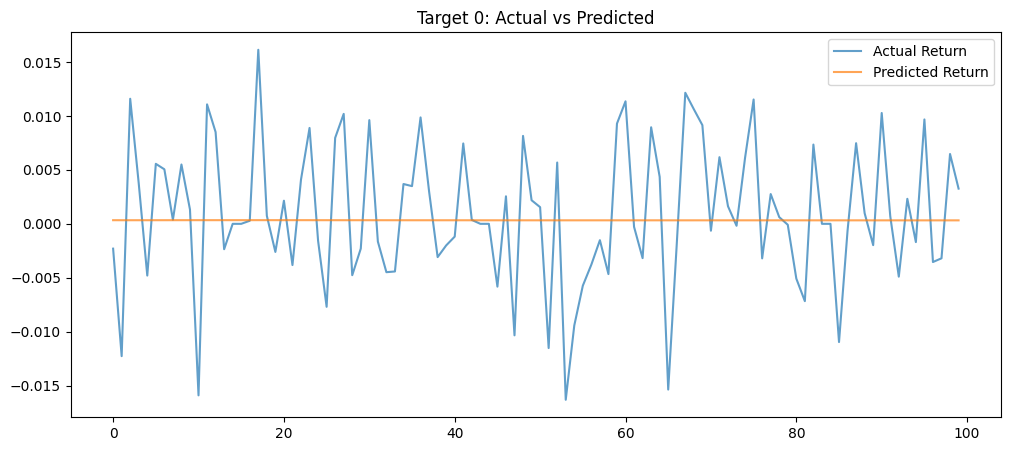

In [21]:
# 2. Pick a random target (e.g., Target 0) and a small slice of time
target_idx = 0 
plt.figure(figsize=(12, 5))
plt.plot(y_val[:100, target_idx], label='Actual Return', alpha=0.7)
plt.plot(y_pred[:100, target_idx], label='Predicted Return', alpha=0.7)
plt.title(f'Target {target_idx}: Actual vs Predicted')
plt.legend()
plt.show()

In [22]:
# 3. Calculate Overall Correlation (The competition metric)
from scipy.stats import spearmanr
correlations = []
for i in range(y_val.shape[1]):
    corr, _ = spearmanr(y_val[:, i], y_pred[:, i])
    correlations.append(corr)

print(f"Average Spearman Correlation across all 424 targets: {np.mean(correlations):.4f}")

Average Spearman Correlation across all 424 targets: 0.0069


TESTING

In [23]:
# 1. Generate predictions for the validation set
y_pred = model.predict(X_val)

# 2. Create the 'solution' DataFrame (The Ground Truth)
# We need to add 'date_id' back as a dummy index for the score function to work
target_col_names = [f'target_{i}' for i in range(424)]
solution_df = pd.DataFrame(y_val, columns=target_col_names)
solution_df['date_id'] = range(len(solution_df))

# 3. Create the 'submission' DataFrame (The Model Predictions)
submission_df = pd.DataFrame(y_pred, columns=target_col_names)
submission_df['date_id'] = range(len(submission_df))

# 4. Define the row_id column required by the score function
ROW_ID_NAME = 'date_id'

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [25]:
import numpy as np
import pandas as pd

SOLUTION_NULL_FILLER = -999999

def rank_correlation_sharpe_ratio(merged_df: pd.DataFrame) -> float:
    prediction_cols = [col for col in merged_df.columns if col.startswith('prediction_')]
    target_cols = [col for col in merged_df.columns if col.startswith('target_')]

    def _compute_rank_correlation(row):
        # Identify non-null targets
        non_null_targets = [col for col in target_cols if not pd.isnull(row[col])]
        matching_predictions = [col for col in prediction_cols if col.replace('prediction', 'target') in non_null_targets]
        
        if not non_null_targets:
            return 0.0
        
        # Calculate standard deviation to check for constant values
        target_std = row[non_null_targets].std(ddof=0)
        pred_std = row[matching_predictions].std(ddof=0)
        
        if target_std == 0 or pred_std == 0:
            return 0.0 # Return 0 correlation if there's no variance
            
        # Compute Spearman Rank Correlation
        return row[matching_predictions].rank().corr(row[non_null_targets].rank())

    daily_rank_corrs = merged_df.apply(_compute_rank_correlation, axis=1)
    
    std_dev = daily_rank_corrs.std(ddof=0)
    if std_dev == 0 or np.isnan(std_dev):
        return 0.0
        
    sharpe_ratio = daily_rank_corrs.mean() / std_dev
    return float(sharpe_ratio)

def score(solution: pd.DataFrame, submission: pd.DataFrame, row_id_column_name: str) -> float:
    # Work on copies to avoid modifying original DataFrames
    sol = solution.copy()
    sub = submission.copy()
    
    del sol[row_id_column_name]
    del sub[row_id_column_name]
    
    # Rename submission columns to prediction_X
    sub.columns = [f"prediction_{i}" for i in range(len(sub.columns))]
    
    # Replace the competition's null filler
    sol = sol.replace(SOLUTION_NULL_FILLER, np.nan)
    
    return rank_correlation_sharpe_ratio(pd.concat([sol, sub], axis='columns'))

In [26]:
final_score = score(solution_df, submission_df, ROW_ID_NAME)
print(f"--- Final Evaluation ---")
print(f"Sharpe Ratio of Rank Correlation: {final_score:.4f}")

--- Final Evaluation ---
Sharpe Ratio of Rank Correlation: 0.0000
